In [ ]:
import numpy as np
import pandas as pd
import pickle as pkl
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, PredefinedSplit, GridSearchCV
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from xgboost import plot_importance
from sklearn.metrics import classification_report

In [ ]:
data = pd.read_csv("tiktok_dataset.csv")

In [ ]:
# Display first few rows
### YOUR CODE HERE ###
data.head(10)

,#,claim_status,video_id,video_duration_sec,video_transcription_text,verified_status,author_ban_status,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count
0,1,claim,7017666017,59,someone shared with me that drone deliveries a...,not verified,under review,343296.0,19425.0,241.0,1.0,0.0
1,2,claim,4014381136,32,someone shared with me that there are more mic...,not verified,active,140877.0,77355.0,19034.0,1161.0,684.0
2,3,claim,9859838091,31,someone shared with me that american industria...,not verified,active,902185.0,97690.0,2858.0,833.0,329.0
3,4,claim,1866847991,25,someone shared with me that the metro of st. p...,not verified,active,437506.0,239954.0,34812.0,1234.0,584.0
4,5,claim,7105231098,19,someone shared with me that the number of busi...,not verified,active,56167.0,34987.0,4110.0,547.0,152.0
5,6,claim,8972200955,35,someone shared with me that gross domestic pro...,not verified,under review,336647.0,175546.0,62303.0,4293.0,1857.0
6,7,claim,4958886992,16,someone shared with me that elvis presley has ...,not verified,active,750345.0,486192.0,193911.0,8616.0,5446.0
7,8,claim,2270982263,41,someone shared with me that the best selling s...,not verified,active,547532.0,1072.0,50.0,22.0,11.0
8,9,claim,5235769692,50,someone shared with me that about half of the ...,not verified,active,24819.0,10160.0,1050.0,53.0,27.0
9,10,claim,4660861094,45,someone shared with me that it would take a 50...,verified,active,931587.0,171051.0,67739.0,4104.0,2540.0


In [ ]:
# Number of rows and columns
data.shape

(19382, 12)

In [ ]:
data.dtypes

#                             int64
claim_status                 object
video_id                      int64
video_duration_sec            int64
video_transcription_text     object
verified_status              object
author_ban_status            object
video_view_count            float64
video_like_count            float64
video_share_count           float64
video_download_count        float64
video_comment_count         float64
dtype: object

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19382 entries, 0 to 19381
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   #                         19382 non-null  int64  
 1   claim_status              19084 non-null  object 
 2   video_id                  19382 non-null  int64  
 3   video_duration_sec        19382 non-null  int64  
 4   video_transcription_text  19084 non-null  object 
 5   verified_status           19382 non-null  object 
 6   author_ban_status         19382 non-null  object 
 7   video_view_count          19084 non-null  float64
 8   video_like_count          19084 non-null  float64
 9   video_share_count         19084 non-null  float64
 10  video_download_count      19084 non-null  float64
 11  video_comment_count       19084 non-null  float64
dtypes: float64(5), int64(3), object(4)
memory usage: 1.8+ MB


In [ ]:
data.describe()

,#,video_id,video_duration_sec,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count
count,19382.000000,1.938200e+04,19382.000000,19084.000000,19084.000000,19084.000000,19084.000000,19084.000000
mean,9691.500000,5.627454e+09,32.421732,254708.558688,84304.636030,16735.248323,1049.429627,349.312146
std,5595.245794,2.536440e+09,16.229967,322893.280814,133420.546814,32036.174350,2004.299894,799.638865
min,1.000000,1.234959e+09,5.000000,20.000000,0.000000,0.000000,0.000000,0.000000
25%,4846.250000,3.430417e+09,18.000000,4942.500000,810.750000,115.000000,7.000000,1.000000
50%,9691.500000,5.618664e+09,32.000000,9954.500000,3403.500000,717.000000,46.000000,9.000000
75%,14536.750000,7.843960e+09,47.000000,504327.000000,125020.000000,18222.000000,1156.250000,292.000000
max,19382.000000,9.999873e+09,60.000000,999817.000000,657830.000000,256130.000000,14994.000000,9599.000000


In [ ]:
# Check for missing values
data.isna().any(axis=1).sum()

298

In [ ]:
# Drop rows with missing values
data = data.dropna(axis=0)

In [ ]:
data.head(10)

,#,claim_status,video_id,video_duration_sec,video_transcription_text,verified_status,author_ban_status,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count
0,1,claim,7017666017,59,someone shared with me that drone deliveries a...,not verified,under review,343296.0,19425.0,241.0,1.0,0.0
1,2,claim,4014381136,32,someone shared with me that there are more mic...,not verified,active,140877.0,77355.0,19034.0,1161.0,684.0
2,3,claim,9859838091,31,someone shared with me that american industria...,not verified,active,902185.0,97690.0,2858.0,833.0,329.0
3,4,claim,1866847991,25,someone shared with me that the metro of st. p...,not verified,active,437506.0,239954.0,34812.0,1234.0,584.0
4,5,claim,7105231098,19,someone shared with me that the number of busi...,not verified,active,56167.0,34987.0,4110.0,547.0,152.0
5,6,claim,8972200955,35,someone shared with me that gross domestic pro...,not verified,under review,336647.0,175546.0,62303.0,4293.0,1857.0
6,7,claim,4958886992,16,someone shared with me that elvis presley has ...,not verified,active,750345.0,486192.0,193911.0,8616.0,5446.0
7,8,claim,2270982263,41,someone shared with me that the best selling s...,not verified,active,547532.0,1072.0,50.0,22.0,11.0
8,9,claim,5235769692,50,someone shared with me that about half of the ...,not verified,active,24819.0,10160.0,1050.0,53.0,27.0
9,10,claim,4660861094,45,someone shared with me that it would take a 50...,verified,active,931587.0,171051.0,67739.0,4104.0,2540.0


In [ ]:
# Check for duplicates
data.duplicated().sum()

0

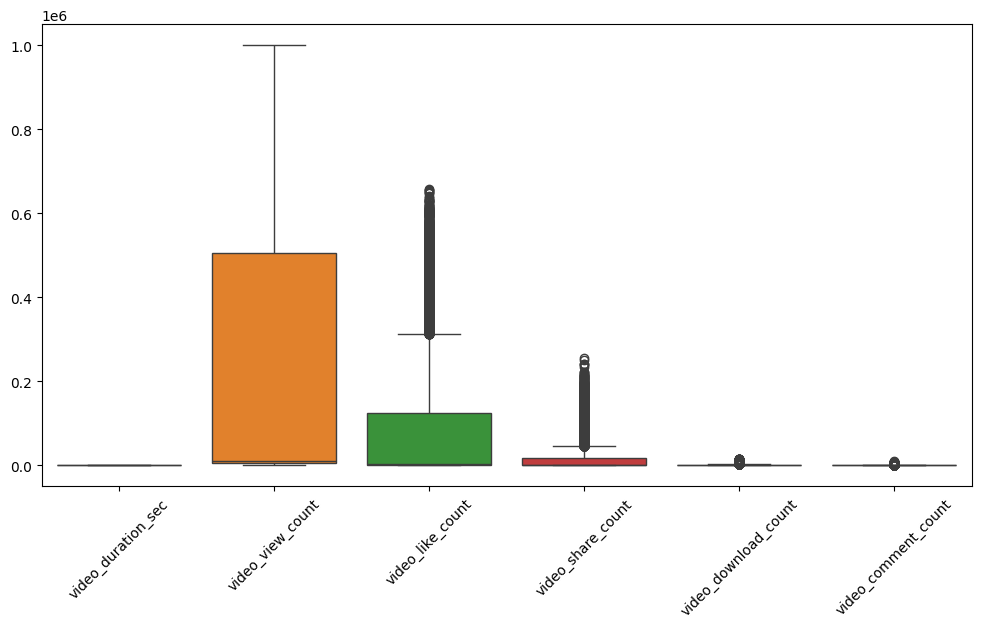

In [ ]:
#Check for outliers
plt.figure(figsize=(12, 6))
num_cols=[
    'video_duration_sec','video_view_count','video_like_count','video_share_count','video_download_count','video_comment_count'   
]
sns.boxplot(data=data[num_cols])
plt.xticks(rotation=45)
plt.show()

In [ ]:
#Handle outliers
for col in num_cols:
        data[col] = np.log1p(data[col])

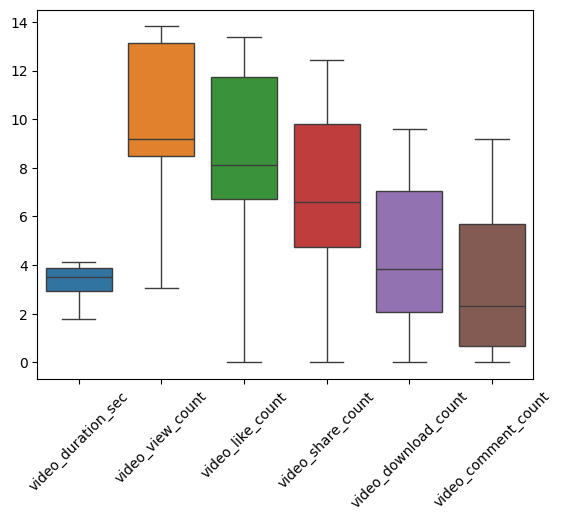

In [14]:
sns.boxplot(data=data[num_cols])
plt.xticks(rotation=45)
plt.show()

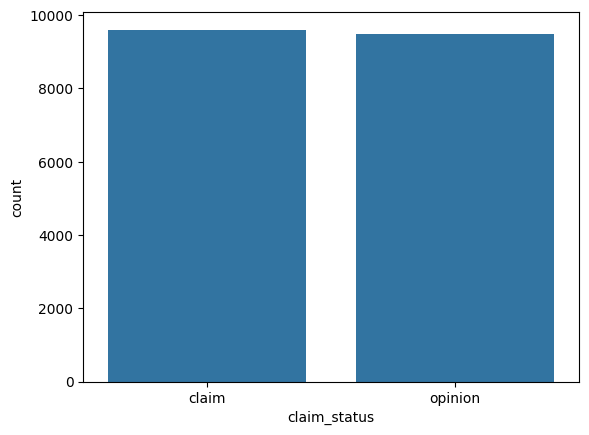

In [ ]:
# Check class balance
sns.countplot(x='claim_status', data=data)
plt.show()

In [ ]:
# Extracting the length of each `video_transcription_text` and adding this as a column to the dataframe
data["text_length"] = data["video_transcription_text"].str.len()
data.head(10)

,#,claim_status,video_id,video_duration_sec,video_transcription_text,verified_status,author_ban_status,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count,text_length
0,1,claim,7017666017,4.094345,someone shared with me that drone deliveries a...,not verified,under review,12.746351,9.874368,5.488938,0.693147,0.000000,97
1,2,claim,4014381136,3.496508,someone shared with me that there are more mic...,not verified,active,11.855650,11.256173,9.854035,7.057898,6.529419,107
2,3,claim,9859838091,3.465736,someone shared with me that american industria...,not verified,active,13.712576,11.489565,7.958227,6.726233,5.799093,137
3,4,claim,1866847991,3.258097,someone shared with me that the metro of st. p...,not verified,active,12.988848,12.388207,10.457746,7.118826,6.371612,131
4,5,claim,7105231098,2.995732,someone shared with me that the number of busi...,not verified,active,10.936102,10.462760,8.321422,6.306275,5.030438,128
5,6,claim,8972200955,3.583519,someone shared with me that gross domestic pro...,not verified,under review,12.726793,12.075662,11.039781,8.364974,7.527256,127
6,7,claim,4958886992,2.833213,someone shared with me that elvis presley has ...,not verified,active,13.528290,13.094361,12.175160,9.061492,8.602820,95
7,8,claim,2270982263,3.737670,someone shared with me that the best selling s...,not verified,active,13.213178,6.978214,3.931826,3.135494,2.484907,99
8,9,claim,5235769692,3.931826,someone shared with me that about half of the ...,not verified,active,10.119405,9.226312,6.957497,3.988984,3.332205,103
9,10,claim,4660861094,3.828641,someone shared with me that it would take a 50...,verified,active,13.744646,12.049723,11.123432,8.319961,7.840313,102


In [ ]:
# Calculating the average text_length for claims and opinions
data[['claim_status', 'text_length']].groupby('claim_status').mean()

,text_length
claim_status,
claim,95.376978
opinion,82.722562


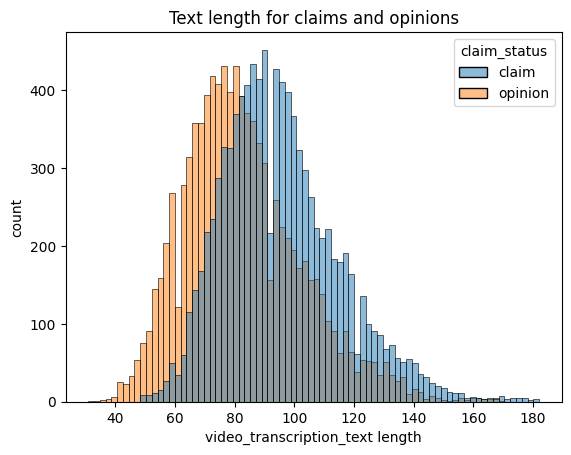

In [ ]:
# Visualizing the distribution of `text_length` for claims and opinions
sns.histplot(
    data=data,
    x="text_length",
    hue="claim_status"
)

plt.xlabel("video_transcription_text length")
plt.ylabel("count")
plt.title("Text length for claims and opinions")
plt.show()

In [ ]:
# Create a copy of the X data
X = data.copy()
# Drop unnecessary columns
X = X.drop(['#', 'video_id'], axis=1)
# Encode target variable
X['claim_status'] = X['claim_status'].replace({
    'opinion': 0,
    'claim': 1
})
# Dummy encode remaining categorical values
X = pd.get_dummies(
    X,
    columns=['verified_status', 'author_ban_status'],
    drop_first=True
)
X.head(10)

,claim_status,video_duration_sec,video_transcription_text,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count,text_length,verified_status_verified,author_ban_status_banned,author_ban_status_under review
0,1,4.094345,someone shared with me that drone deliveries a...,12.746351,9.874368,5.488938,0.693147,0.000000,97,False,False,True
1,1,3.496508,someone shared with me that there are more mic...,11.855650,11.256173,9.854035,7.057898,6.529419,107,False,False,False
2,1,3.465736,someone shared with me that american industria...,13.712576,11.489565,7.958227,6.726233,5.799093,137,False,False,False
3,1,3.258097,someone shared with me that the metro of st. p...,12.988848,12.388207,10.457746,7.118826,6.371612,131,False,False,False
4,1,2.995732,someone shared with me that the number of busi...,10.936102,10.462760,8.321422,6.306275,5.030438,128,False,False,False
5,1,3.583519,someone shared with me that gross domestic pro...,12.726793,12.075662,11.039781,8.364974,7.527256,127,False,False,True
6,1,2.833213,someone shared with me that elvis presley has ...,13.528290,13.094361,12.175160,9.061492,8.602820,95,False,False,False
7,1,3.737670,someone shared with me that the best selling s...,13.213178,6.978214,3.931826,3.135494,2.484907,99,False,False,False
8,1,3.931826,someone shared with me that about half of the ...,10.119405,9.226312,6.957497,3.988984,3.332205,103,False,False,False
9,1,3.828641,someone shared with me that it would take a 50...,13.744646,12.049723,11.123432,8.319961,7.840313,102,True,False,False


In [ ]:
# Isolate target variable
y = X['claim_status']

In [ ]:
# Isolate features
X = X.drop(['claim_status'], axis=1)
X.head()

,video_duration_sec,video_transcription_text,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count,text_length,verified_status_verified,author_ban_status_banned,author_ban_status_under review
0,4.094345,someone shared with me that drone deliveries a...,12.746351,9.874368,5.488938,0.693147,0.000000,97,False,False,True
1,3.496508,someone shared with me that there are more mic...,11.855650,11.256173,9.854035,7.057898,6.529419,107,False,False,False
2,3.465736,someone shared with me that american industria...,13.712576,11.489565,7.958227,6.726233,5.799093,137,False,False,False
3,3.258097,someone shared with me that the metro of st. p...,12.988848,12.388207,10.457746,7.118826,6.371612,131,False,False,False
4,2.995732,someone shared with me that the number of busi...,10.936102,10.462760,8.321422,6.306275,5.030438,128,False,False,False


In [ ]:
# Split the data into training and testing sets, 80/20
X_tr, X_test, y_tr, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [ ]:
# Split the training data into training and validation sets 75/25
# Final split 60/20/20, train/validate/test.
X_train, X_val, y_train, y_val = train_test_split(X_tr, y_tr, test_size=0.25, random_state=0)

In [ ]:
X_train.shape, X_val.shape, X_test.shape, y_train.shape, y_val.shape, y_test.shape

((11450, 11), (3817, 11), (3817, 11), (11450,), (3817,), (3817,))

In [ ]:
# Using Random Forest
rf = RandomForestClassifier(random_state=0)
# Creating a dictionary of hyperparameters to tune
cv_params = {'max_depth': [5, 7, None],
             'max_features': [0.3, 0.6],
            #  'max_features': 'auto'
             'max_samples': [0.7],
             'min_samples_leaf': [1,2],
             'min_samples_split': [2,3],
             'n_estimators': [75,100,200],
             }

# Define a list of scoring metrics to capture
scoring = ['accuracy', 'precision', 'recall', 'f1']
# Instantiate the GridSearchCV object
rf_cv = GridSearchCV(rf, cv_params, scoring=scoring, cv=5, refit='recall')

In [26]:
X_train.dtypes

video_duration_sec                float64
video_transcription_text           object
video_view_count                  float64
video_like_count                  float64
video_share_count                 float64
video_download_count              float64
video_comment_count               float64
text_length                         int64
verified_status_verified             bool
author_ban_status_banned             bool
author_ban_status_under review       bool
dtype: object

In [27]:
X_train = X_train.drop(columns=['video_transcription_text'])
X_test = X_test.drop(columns=['video_transcription_text'])

In [ ]:
%%time
# Fit the model to the data 
rf_cv.fit(X_train, y_train)

CPU times: user 5min 51s, sys: 884 ms, total: 5min 52s
Wall time: 5min 52s


GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=0),
             param_grid={'max_depth': [5, 7, None], 'max_features': [0.3, 0.6],
                         'max_samples': [0.7], 'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 3],
                         'n_estimators': [75, 100, 200]},
             refit='recall', scoring=['accuracy', 'precision', 'recall', 'f1'])

In [ ]:
# Examine best recall score
rf_cv.best_score_

0.9908534395531852

In [ ]:
# Examine best parameters
rf_cv.best_params_

{'max_depth': 5,
 'max_features': 0.6,
 'max_samples': 0.7,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'n_estimators': 75}

In [ ]:
# Access the GridSearch results and convert it to a pandas df
rf_results_df = pd.DataFrame(rf_cv.cv_results_)
# Examine the GridSearch results df at column `mean_test_precision` in the best index
rf_results_df['mean_test_precision'][rf_cv.best_index_]

0.9994785483051682

In [36]:
def conf_matrix_plot(model, x_data, y_data):
   
  
    model_pred = model.predict(x_data)
    cm = confusion_matrix(y_data, model_pred, labels=model.classes_)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                             display_labels=model.classes_)
  
    disp.plot(values_format='')  # `values_format=''` suppresses scientific notation
    plt.show()

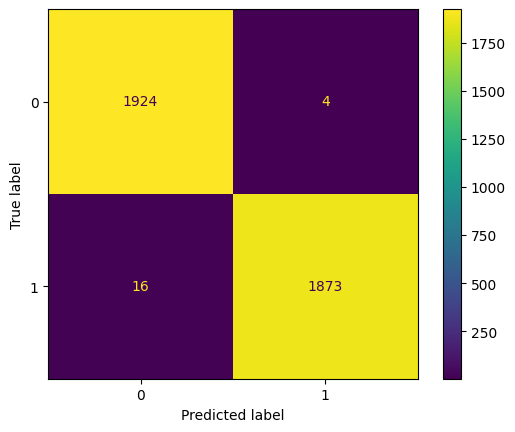

In [37]:
conf_matrix_plot(rf_cv, X_test, y_test)

In [ ]:
# Same as above Using XGBoost
xgb = XGBClassifier(objective='binary:logistic', random_state=0)
cv_params = {'max_depth': [4,8,12],
             'min_child_weight': [3, 5],
             'learning_rate': [0.01, 0.1],
             'n_estimators': [300, 500]
             }
scoring = ['accuracy', 'precision', 'recall', 'f1']
xgb_cv = GridSearchCV(xgb, cv_params, scoring=scoring, cv=5, refit='recall')

In [ ]:
%%time
xgb_cv.fit(X_train, y_train)

CPU times: user 1min 3s, sys: 1.34 s, total: 1min 5s
Wall time: 33.7 s


GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate=None,...
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None,
                                     random_state=0, ...),
             param_grid={'learning_rate': [0.01, 0.1], 'max_depth': [4, 8, 12],
                         'min_child_weight': [3, 5],
                         'n_estimators': [300, 500]},
             refit='recall', scoring=['accuracy', 'precision', 'recall', 'f1'])

In [ ]:
xgb_cv.best_score_

0.9898176171763818

In [ ]:
xgb_cv.best_params_

{'learning_rate': 0.1,
 'max_depth': 4,
 'min_child_weight': 5,
 'n_estimators': 300}

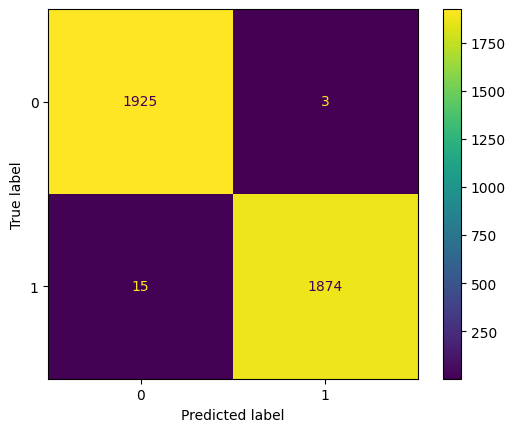

In [46]:
conf_matrix_plot(xgb_cv, X_test, y_test)

In [ ]:
# Access the GridSearch results and convert it to a pandas df
xgb_results_df = pd.DataFrame(xgb_cv.cv_results_)
# Examine the GridSearch results df at column `mean_test_precision` in the best index
xgb_results_df['mean_test_precision'][xgb_cv.best_index_]

0.9989540885869099

In [ ]:
# Validation for RandomForest
X_val.head()
X_val = X_val.drop(columns=['video_transcription_text'])
y_pred = rf_cv.best_estimator_.predict(X_val)

KeyError: "['video_transcription_text'] not found in axis"

In [ ]:
# Use the random forest "best estimator" model to get predictions on the validation set
y_pred = rf_cv.best_estimator_.predict(X_val)

In [ ]:
# Display the predictions on the validation set
y_pred

array([1, 0, 1, ..., 1, 1, 1])

In [ ]:
# Display the true labels of the validation set
y_val

5846     1
12058    0
2975     1
8432     1
6863     1
        ..
6036     1
6544     1
2781     1
6426     1
4450     1
Name: claim_status, Length: 3817, dtype: int64

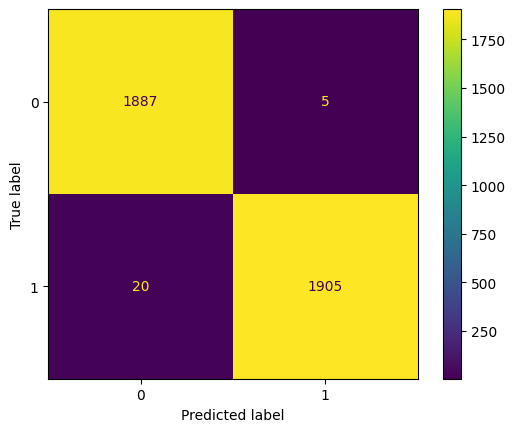

In [ ]:
conf_matrix_plot(rf_cv, X_val[X_train.columns], y_val)

In [ ]:
# Create a classification report
target_labels = ['opinion', 'claim']
print(classification_report(y_val, y_pred, target_names=target_labels))

              precision    recall  f1-score   support

     opinion       0.99      1.00      0.99      1892
       claim       1.00      0.99      0.99      1925

    accuracy                           0.99      3817
   macro avg       0.99      0.99      0.99      3817
weighted avg       0.99      0.99      0.99      3817



5 false positive and 20 false negative

In [ ]:
# Same as above for XGBoost
y_pred = xgb_cv.best_estimator_.predict(X_val)
y_pred

array([1, 0, 1, ..., 1, 1, 1])

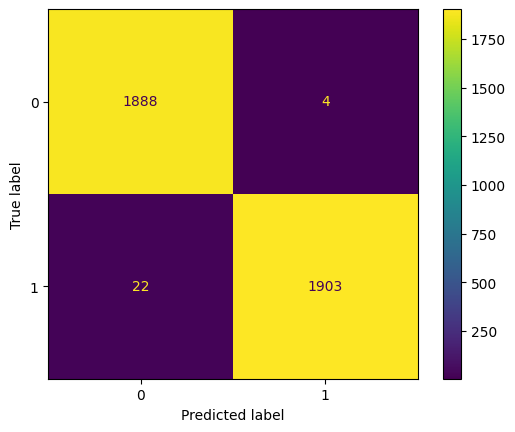

In [ ]:
conf_matrix_plot(xgb_cv, X_val[X_train.columns], y_val)

In [ ]:
target_labels = ['opinion', 'claim']
print(classification_report(y_val, y_pred, target_names=target_labels))

              precision    recall  f1-score   support

     opinion       0.99      1.00      0.99      1892
       claim       1.00      0.99      0.99      1925

    accuracy                           0.99      3817
   macro avg       0.99      0.99      0.99      3817
weighted avg       0.99      0.99      0.99      3817



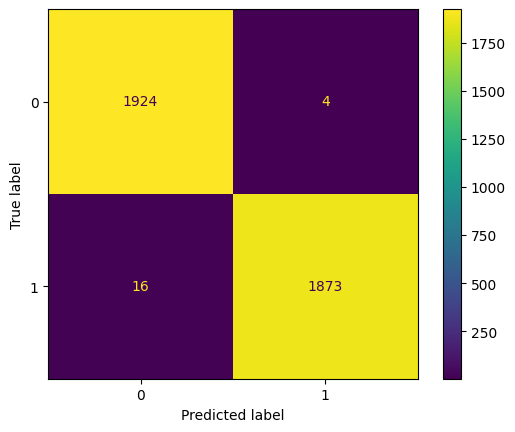

In [ ]:
#Using random forest on test data since it got more true positive
conf_matrix_plot(rf_cv, X_test, y_test)

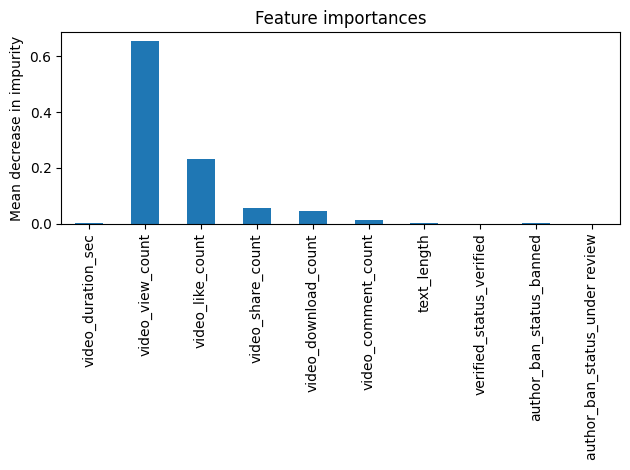

In [ ]:
# Feature importances
importances = rf_cv.best_estimator_.feature_importances_
rf_importances = pd.Series(importances, index=X_test.columns)

fig, ax = plt.subplots()
rf_importances.plot.bar(ax=ax)
ax.set_title('Feature importances')
ax.set_ylabel('Mean decrease in impurity')
fig.tight_layout()